## Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from datasets import Dataset
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

## Load data

In [7]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)

In [76]:
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]
feature_names = data.drop(columns=["participant_id", "session_id", "task_name", 
                                    "participant_id_int"] + disorders).columns.tolist()

y_voice = data["Voice Disorders"].copy().to_numpy()
X = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).to_numpy()

In [30]:
data.head()

,participant_id,session_id,task_name,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,range_ratio_intensity_db,std_hnr_db,stoi,pesq,si_sdr,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders,participant_id_int
0,004d42e9,07031CC3,Animal-fluency,30.849073,0.205649,26.938833,32.299248,36.319099,9.380266,321.246490,...,2.522056,6.754861,0.594471,1.159233,-14.364435,0,1,1,0,0
26,004d42e9,07031CC3,Productive-Vocabulary-1,34.447186,0.057132,32.960548,33.506256,36.057877,3.097328,100.624840,...,2.078612,7.996467,0.802794,1.277508,-0.301972,0,1,1,0,0
27,004d42e9,07031CC3,Productive-Vocabulary-2,35.895359,0.092448,33.253757,35.642937,37.830379,4.576622,381.294708,...,1.813655,7.262162,0.742845,1.199748,-1.893810,0,1,1,0,0
28,004d42e9,07031CC3,Productive-Vocabulary-3,35.248405,0.101374,33.987968,36.224056,37.653236,3.665268,85.709679,...,2.088298,7.535089,0.705393,1.185849,-3.215629,0,1,1,0,0
29,004d42e9,07031CC3,Productive-Vocabulary-4,33.798946,0.114689,32.843185,34.022396,36.028976,3.185791,158.320511,...,1.864071,6.776752,0.818446,1.240876,-1.725452,0,1,1,0,0


## Preprocessing

### Average over sessions within subject

In [9]:
n_subj = groups[-1]+1
X_ave = np.zeros((n_subj, X.shape[1]))
y_voice_ave = np.zeros(n_subj)
for g in np.arange(n_subj):
    curr_X = X[np.where(groups==g)].mean(axis=0)
    X_ave[g] = curr_X
    y_voice_ave[g] = y_voice[np.where(groups==g)].mean()
print(X_ave.shape)

(442, 96)


## Train Logistic Regression

In [44]:
# Run GridSearchCV only for Voice disorder and visualize all combinations' train vs validation performance
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def grid_search(param_grid:dict, y_curr, label:str, n_splits:int=10):
    # Split off a held-out test set (never used for CV)
    X_tr, X_te, y_tr, y_te = train_test_split(X_ave, y_curr, test_size=0.15, random_state=42, stratify=y_curr)

    # Create a pipeline with StandardScaler and LogisticRegression
    # Logistic Regression benefits from feature scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            random_state=42, 
            max_iter=5000,  # Increased significantly
            tol=1e-4,       # Convergence tolerance
            warm_start=False
        ))
    ])
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    gscv = GridSearchCV(pipeline, param_grid, scoring='f1_weighted', cv=skf, n_jobs=-1, refit=True, return_train_score=True)
    gscv.fit(X_tr, y_tr)

    # Convert cv_results_ into a DataFrame for easier analysis
    cv_res = pd.DataFrame(gscv.cv_results_)
    # keep only relevant cols
    cols = ['params','mean_train_score','std_train_score','mean_test_score','std_test_score','rank_test_score']
    summary_grid = cv_res[cols].sort_values('rank_test_score').reset_index(drop=True)

    print('Top 5 hyperparameter combinations (by validation rank):')
    for i, row in summary_grid.head(5).iterrows():
        print(f"Rank {int(row['rank_test_score'])}: val={row['mean_test_score']:.4f}, train={row['mean_train_score']:.4f}, params={row['params']}")

    # Scatter plot: train vs validation for every combo
    fig, ax = plt.subplots(figsize=(8,6))
    x = summary_grid['mean_train_score']
    y = summary_grid['mean_test_score']
    sc = ax.scatter(x, y, c=summary_grid['rank_test_score'], cmap='viridis', s=60, edgecolor='k')
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=1)  # reference line where train==val
    ax.set_xlabel('Mean Train F1 (CV)')
    ax.set_ylabel('Mean Validation F1 (CV)')
    ax.set_title('Train vs Validation F1 for all hyperparameter combinations (Voice)')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Rank (lower is better)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot the overfitting gap (train - val) sorted by rank
    summary_grid['train_minus_val'] = summary_grid['mean_train_score'] - summary_grid['mean_test_score']
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(range(len(summary_grid)), summary_grid['train_minus_val'], color='C1')
    ax.set_xlabel('Hyperparameter combination (sorted by validation rank)')
    ax.set_ylabel('Train F1 - Validation F1')
    ax.set_title('Overfitting gap per hyperparameter combination (Voice)')
    plt.tight_layout()
    plt.show()

    # Evaluate best estimator on held-out test set and show report
    best = gscv.best_estimator_
    y_test_pred = best.predict(X_te)
    test_f1 = f1_score(y_te, y_test_pred, average='weighted')
    print('Classification report (test):')
    print(classification_report(y_te, y_test_pred))
    print('Confusion matrix (test):')
    print(confusion_matrix(y_te, y_test_pred))

    # Save results to a dict for later use
    grid_search_results = {'cv_results_df': summary_grid, 'best_params': gscv.best_params_, 'best_score_cv': gscv.best_score_, 'test_f1': test_f1, 'best_estimator': best}
    return grid_search_results


In [42]:
import warnings
warnings.filterwarnings("ignore")

Top 5 hyperparameter combinations (by validation rank):
Rank 1: val=0.7774, train=0.8525, params={'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 2: val=0.7717, train=0.8103, params={'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 3: val=0.7674, train=0.8830, params={'logreg__C': 1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Rank 4: val=0.7667, train=0.8942, params={'logreg__C': 1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 5: val=0.7613, train=0.8051, params={'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}


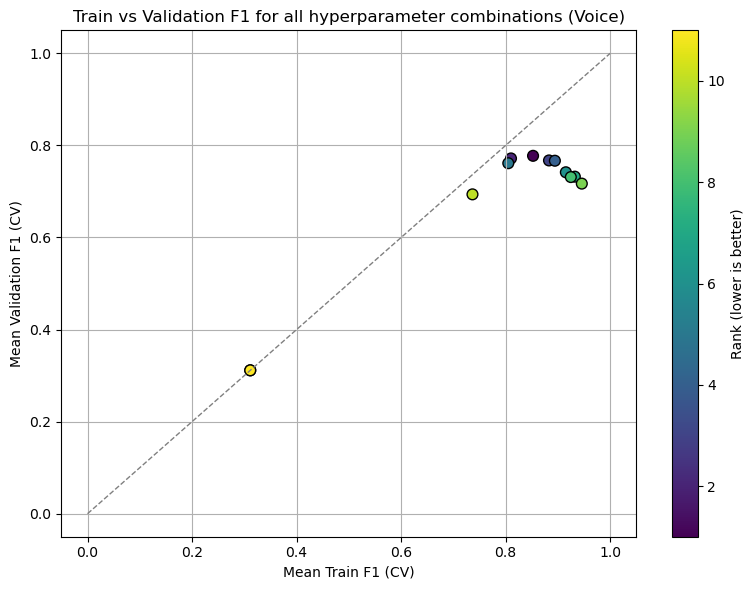

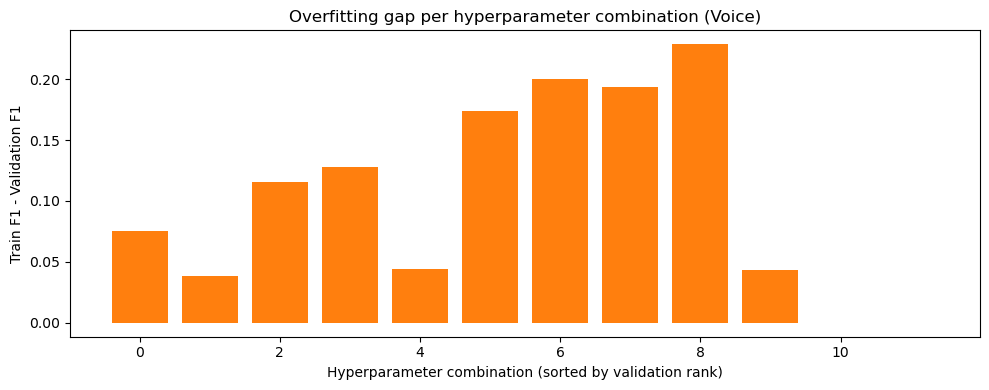

Classification report (test):
              precision    recall  f1-score   support

         0.0       0.72      0.88      0.79        32
         1.0       0.86      0.69      0.76        35

    accuracy                           0.78        67
   macro avg       0.79      0.78      0.78        67
weighted avg       0.79      0.78      0.77        67

Confusion matrix (test):
[[28  4]
 [11 24]]


In [48]:
# Recommended parameter grid for DecisionTreeClassifier (covers regularization and split options)
param_grid_fast = [
    # L2 with lbfgs (fastest)
    {
        'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logreg__penalty': ['l2'],
        'logreg__solver': ['lbfgs']
    },
    # L1 with liblinear (fast)
    {
        'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logreg__penalty': ['l1'],
        'logreg__solver': ['liblinear']
    }
]

grid_search_voice = grid_search(param_grid_fast, y_voice_ave, "Voice")


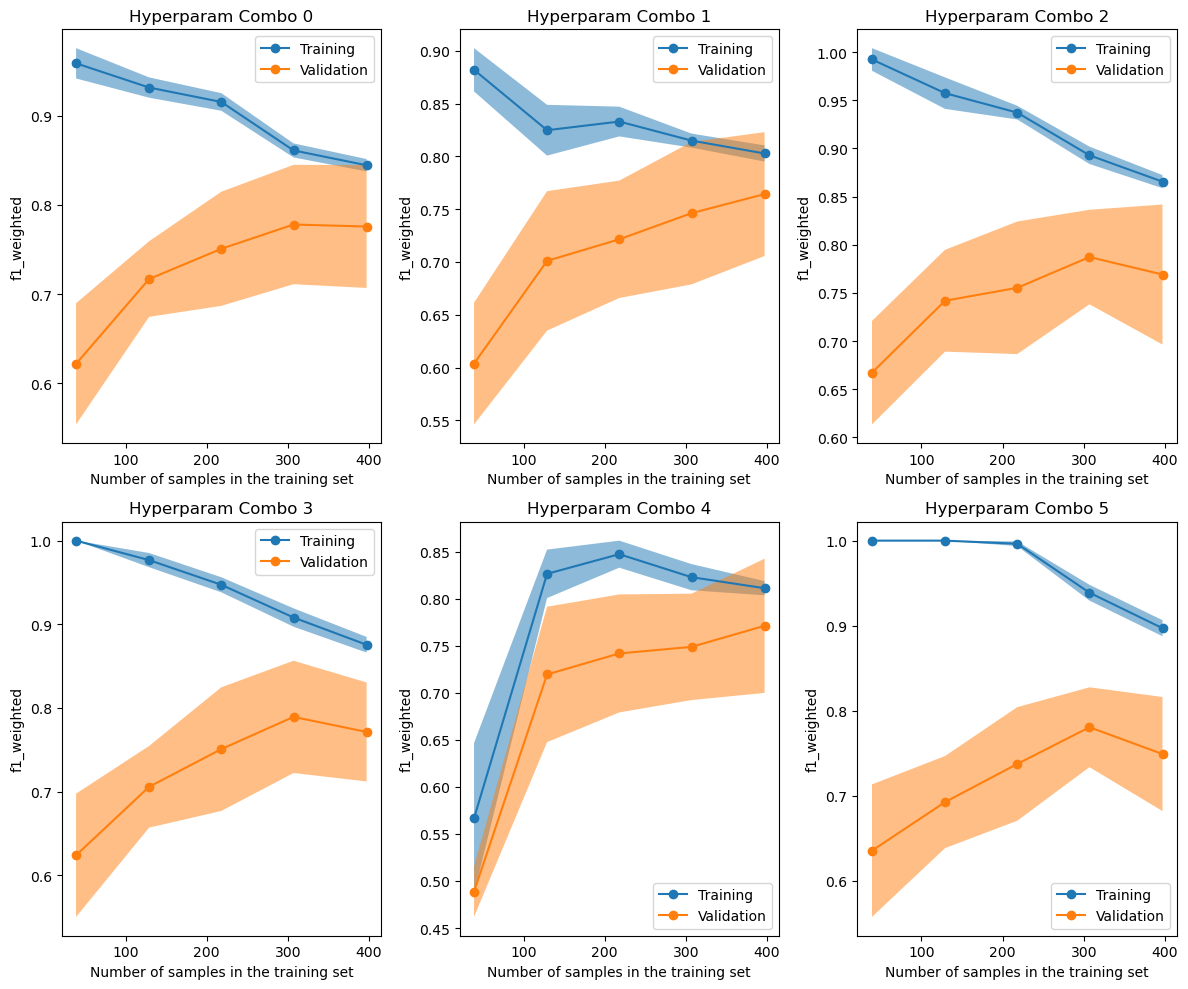

In [51]:


top_params = grid_search_voice["cv_results_df"].sort_values("rank_test_score",ascending=True)[:6]['params'].tolist()
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 10))

common_params = {
    "X": X_ave,
    "y": y_voice_ave,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    "score_type": "both",
    "n_jobs": 1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "f1_weighted",
}

for i, (ax, params) in enumerate(zip(axes.flatten(), top_params)):
    # Extract LogisticRegression parameters from the pipeline params
    logreg_params = {k.replace('logreg__', ''): v for k, v in params.items() if k.startswith('logreg__')}
    
    # Create pipeline with StandardScaler and LogisticRegression
    estimator = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(random_state=42, max_iter=15000, **logreg_params))
    ])
    
    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax)
    
    handles, label = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ["Training", "Validation"])
    ax.set_title(f"Hyperparam Combo {i}") 

plt.tight_layout()
plt.show()

In [52]:
grid_search_voice["cv_results_df"].sort_values(by="train_minus_val",ascending=True)[:10]

,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score,train_minus_val
10,"{'logreg__C': 0.001, 'logreg__penalty': 'l1', ...",0.311353,0.000773,0.311469,0.006958,11,-0.000117
11,"{'logreg__C': 0.01, 'logreg__penalty': 'l1', '...",0.311353,0.000773,0.311469,0.006958,11,-0.000117
1,"{'logreg__C': 0.01, 'logreg__penalty': 'l2', '...",0.810258,0.010739,0.771733,0.085733,2,0.038525
9,"{'logreg__C': 0.001, 'logreg__penalty': 'l2', ...",0.736564,0.013933,0.693709,0.075945,10,0.042855
4,"{'logreg__C': 0.1, 'logreg__penalty': 'l1', 'l...",0.805099,0.010233,0.761342,0.088154,5,0.043757
0,"{'logreg__C': 0.1, 'logreg__penalty': 'l2', 'l...",0.852473,0.006905,0.777424,0.084669,1,0.075048
2,"{'logreg__C': 1, 'logreg__penalty': 'l1', 'log...",0.883000,0.006682,0.767384,0.074313,3,0.115616
3,"{'logreg__C': 1, 'logreg__penalty': 'l2', 'log...",0.894233,0.008730,0.766747,0.081051,4,0.127486
5,"{'logreg__C': 10, 'logreg__penalty': 'l2', 'lo...",0.915258,0.009342,0.741671,0.081740,6,0.173587
7,"{'logreg__C': 10, 'logreg__penalty': 'l1', 'lo...",0.924744,0.013298,0.731279,0.072711,8,0.193465


In [53]:
grid_search_voice["cv_results_df"].sort_values(by="rank_test_score",ascending=True)[:10]

,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score,train_minus_val
0,"{'logreg__C': 0.1, 'logreg__penalty': 'l2', 'l...",0.852473,0.006905,0.777424,0.084669,1,0.075048
1,"{'logreg__C': 0.01, 'logreg__penalty': 'l2', '...",0.810258,0.010739,0.771733,0.085733,2,0.038525
2,"{'logreg__C': 1, 'logreg__penalty': 'l1', 'log...",0.883000,0.006682,0.767384,0.074313,3,0.115616
3,"{'logreg__C': 1, 'logreg__penalty': 'l2', 'log...",0.894233,0.008730,0.766747,0.081051,4,0.127486
4,"{'logreg__C': 0.1, 'logreg__penalty': 'l1', 'l...",0.805099,0.010233,0.761342,0.088154,5,0.043757
5,"{'logreg__C': 10, 'logreg__penalty': 'l2', 'lo...",0.915258,0.009342,0.741671,0.081740,6,0.173587
6,"{'logreg__C': 100, 'logreg__penalty': 'l2', 'l...",0.932445,0.013379,0.732141,0.074826,7,0.200303
7,"{'logreg__C': 10, 'logreg__penalty': 'l1', 'lo...",0.924744,0.013298,0.731279,0.072711,8,0.193465
8,"{'logreg__C': 100, 'logreg__penalty': 'l1', 'l...",0.945769,0.012381,0.717032,0.092268,9,0.228737
9,"{'logreg__C': 0.001, 'logreg__penalty': 'l2', ...",0.736564,0.013933,0.693709,0.075945,10,0.042855


## Group K Fold
- Leave one group out is making the model overfit because the test folds are too small. Let's try leaving out more groups than one.

In [54]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

In [32]:
n_train_groups = len(np.unique(groups[train_idx]))
ideal_n_test_groups = int(n_train_groups*0.15)
ave_n_sessions_per_group = int(len(groups[train_idx])/n_train_groups)
ideal_n_test_inds = ideal_n_test_groups * ave_n_sessions_per_group
n_splits = int(np.ceil(len(groups[train_idx])/ideal_n_test_inds))

In [55]:
# Preprocess, train, and evaluate LogisticRegression with LOGO and record per-fold train/val metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

gkf = GroupKFold(n_splits=n_splits)
fold_results = []

for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/validation split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[te_idx], y_train[te_idx]

    # Create pipeline with StandardScaler and LogisticRegression
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(random_state=42, max_iter=5000))
    ])

    # Fit on training groups
    clf.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = clf.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(te_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[train_idx][te_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
logistic_regression_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
print(logistic_regression_gkf_fold_results.head(10))

Per-fold GKF results (first 10 rows):
   fold  train_idx_count  val_idx_count  train_f1    val_f1  \
0     0            13784           2300  0.670443  0.696545   
1     1            13801           2283  0.669307  0.710977   
2     2            13801           2283  0.678440  0.594369   
3     3            13775           2309  0.681469  0.604158   
4     4            13774           2310  0.670195  0.676395   
5     5            13787           2297  0.677369  0.647284   
6     6            13782           2302  0.676555  0.657841   

                                          val_groups  
0  [0, 3, 22, 35, 43, 53, 58, 83, 88, 114, 125, 1...  
1  [12, 14, 15, 19, 21, 23, 27, 34, 42, 50, 62, 7...  
2  [6, 18, 37, 38, 48, 61, 69, 72, 75, 85, 99, 10...  
3  [4, 9, 39, 47, 66, 70, 78, 82, 84, 92, 94, 97,...  
4  [5, 11, 13, 17, 20, 31, 36, 41, 44, 59, 63, 65...  
5  [7, 16, 24, 32, 51, 54, 68, 74, 101, 104, 110,...  
6  [8, 30, 33, 40, 55, 56, 57, 60, 80, 87, 100, 1...  


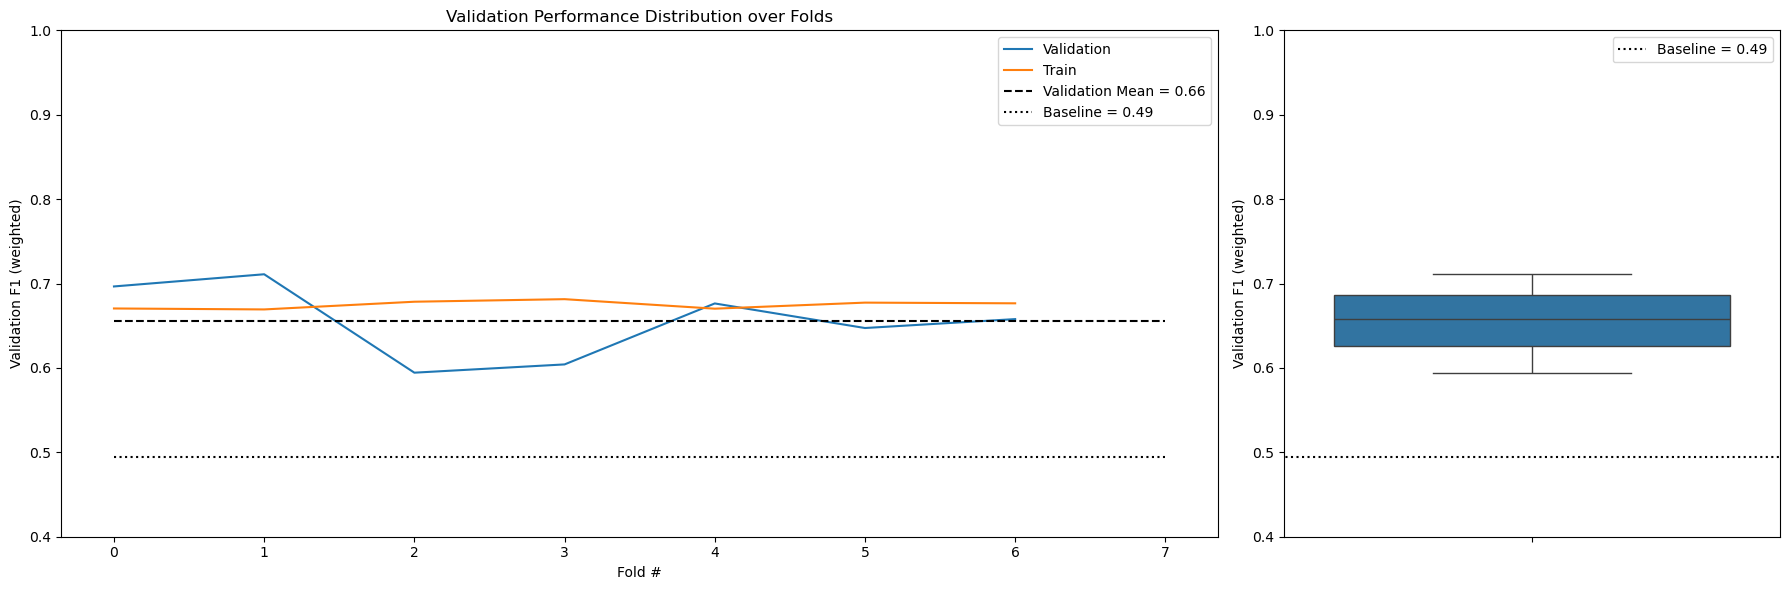

In [56]:
import seaborn as sns

val_mean = logistic_regression_gkf_fold_results["val_f1"].mean()
baseline_mean = y_voice.mean()

fig,axes = plt.subplots(1,2,figsize=(18,6),width_ratios=[0.7,0.3])

sns.lineplot(data=logistic_regression_gkf_fold_results,x="fold",y="val_f1",ax=axes[0],label="Validation")
sns.lineplot(data=logistic_regression_gkf_fold_results,x="fold",y="train_f1",ax=axes[0],label="Train")
axes[0].plot([0,n_splits],[val_mean, val_mean], ls="--",c="k",label=f"Validation Mean = {np.round(val_mean, 2)}")
axes[0].plot([0,n_splits],[baseline_mean, baseline_mean], ls="dotted",c="k",label=f"Baseline = {np.round(baseline_mean, 2)}")
axes[0].set_ylabel("Validation F1 (weighted)")
axes[0].set_ylim([0.4, 1.0])
axes[0].set_xlabel("Fold #")
axes[0].legend()
axes[0].set_title("Validation Performance Distribution over Folds")

sns.boxplot(data=logistic_regression_gkf_fold_results, y="val_f1",ax=axes[1])
axes[1].plot([-1,2], [baseline_mean, baseline_mean], ls="dotted", c="k", label=f"Baseline = {np.round(baseline_mean,2)}")
axes[1].set_ylabel("Validation F1 (weighted)")
axes[1].set_xlim([-0.5, 0.5])
axes[1].set_ylim([0.4, 1.0])
axes[1].legend()
plt.tight_layout()
plt.show()

## Hyperparameter tuning with GroupKFold

In [57]:
# Run GridSearchCV with GroupKFold for Voice disorder and visualize all combinations' train vs validation performance
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

def grid_search(param_grid:dict, X, y, groups, label:str, n_splits:int=7):
    # Create pipeline with StandardScaler and LogisticRegression
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(random_state=42, max_iter=5000))
    ])

    gkf = GroupKFold(n_splits=n_splits)

    gscv = GridSearchCV(pipeline, param_grid, scoring='f1_weighted', cv=gkf, n_jobs=-1, refit=True, return_train_score=True)
    gscv.fit(X, y, groups=groups)

    # Convert cv_results_ into a DataFrame for easier analysis
    cv_res = pd.DataFrame(gscv.cv_results_)
    # keep only relevant cols
    cols = ['params','mean_train_score','std_train_score','mean_test_score','std_test_score','rank_test_score']
    summary_grid = cv_res[cols].sort_values('rank_test_score').reset_index(drop=True)

    print('Top 5 hyperparameter combinations (by validation rank):')
    for i, row in summary_grid.head(5).iterrows():
        print(f"Rank {int(row['rank_test_score'])}: val={row['mean_test_score']:.4f}, train={row['mean_train_score']:.4f}, params={row['params']}")

    # Scatter plot: train vs validation for every combo
    fig, ax = plt.subplots(figsize=(8,6))
    x = summary_grid['mean_train_score']
    y = summary_grid['mean_test_score']
    sc = ax.scatter(x, y, c=summary_grid['rank_test_score'], cmap='viridis', s=60, edgecolor='k')
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=1)  # reference line where train==val
    ax.set_xlabel('Mean Train F1 (CV)')
    ax.set_ylabel('Mean Validation F1 (CV)')
    ax.set_title(f'Train vs Validation F1 for all hyperparameter combinations ({label})')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Rank (lower is better)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot the overfitting gap (train - val) sorted by rank
    summary_grid['train_minus_val'] = summary_grid['mean_train_score'] - summary_grid['mean_test_score']
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(range(len(summary_grid)), summary_grid['train_minus_val'], color='C1')
    ax.set_xlabel('Hyperparameter combination (sorted by validation rank)')
    ax.set_ylabel('Train F1 - Validation F1')
    ax.set_title(f'Overfitting gap per hyperparameter combination ({label})')
    plt.tight_layout()
    plt.show()

    # Best estimator
    best = gscv.best_estimator_

    # Save results to a dict for later use
    grid_search_results = {'cv_results_df': summary_grid, 'best_params': gscv.best_params_, 'best_score_cv': gscv.best_score_, 'best_estimator': best}
    return grid_search_results

Top 5 hyperparameter combinations (by validation rank):
Rank 1: val=0.6552, train=0.6749, params={'logreg__C': 1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 2: val=0.6545, train=0.6748, params={'logreg__C': 10, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 3: val=0.6544, train=0.6744, params={'logreg__C': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 4: val=0.6540, train=0.6728, params={'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Rank 5: val=0.6486, train=0.6656, params={'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}


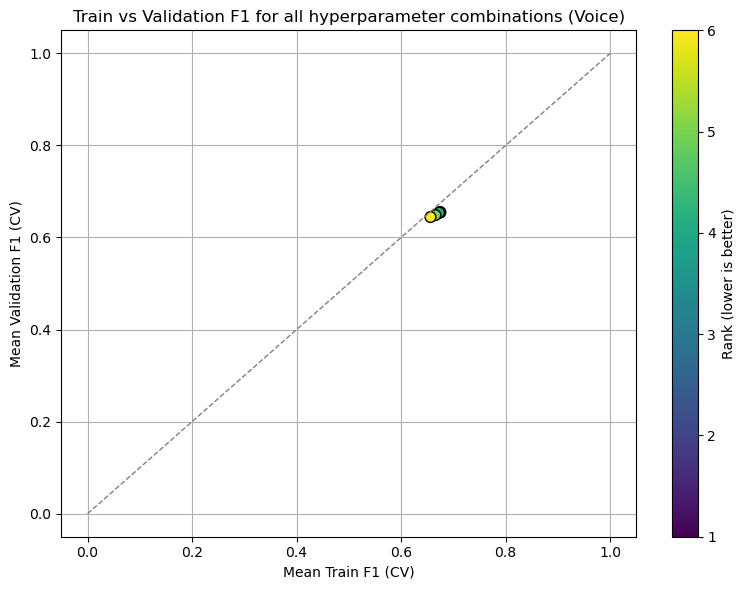

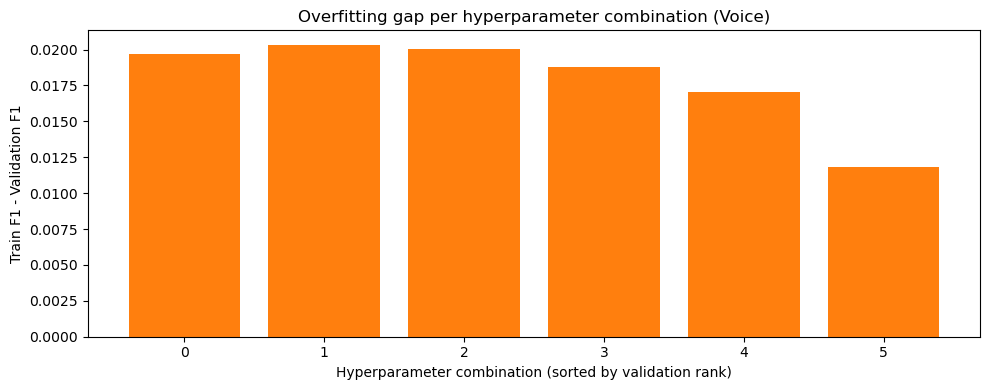

In [59]:

# Parameter grids for Logistic Regression

# OPTION 1: Simple and fast (RECOMMENDED to start)
param_grid_simple = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs']
}

# OPTION 2: L1 and L2 regularization
param_grid_l1_l2 = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['saga']
}

# OPTION 3: Include elasticnet (most comprehensive)
param_grid_full = [
    # L1 and L2 penalties
    {
        'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logreg__penalty': ['l1', 'l2'],
        'logreg__solver': ['saga']
    },
    # Elasticnet penalty
    {
        'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logreg__penalty': ['elasticnet'],
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0.3, 0.5, 0.7]
    }
]

grid_search_voice = grid_search(param_grid_simple, X_train, y_train, groups[train_idx], "Voice", n_splits)

## Train and test for best performing decision tree (that isn't overfitting)

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

gkf = GroupKFold(n_splits=n_splits)
fold_results = []

# Remove 'logreg__' prefix from params
params = {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

# Create pipeline with StandardScaler and LogisticRegression
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=5000, **params))
])

# FIX: Use groups[train_idx] to match the length of X_train and y_train
for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/validation split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    clf.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = clf.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[train_idx][val_idx]).tolist()  # Also fixed this line
    })

# Convert to DataFrame for easier plotting/analysis
logistic_regression_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
print(logistic_regression_gkf_fold_results.head(10))

Per-fold GKF results (first 10 rows):
   fold  train_idx_count  val_idx_count  train_f1    val_f1  \
0     0            13784           2300  0.670443  0.696545   
1     1            13801           2283  0.669307  0.710977   
2     2            13801           2283  0.678440  0.594369   
3     3            13775           2309  0.681469  0.604158   
4     4            13774           2310  0.670195  0.676395   
5     5            13787           2297  0.677369  0.647284   
6     6            13782           2302  0.676555  0.657841   

                                          val_groups  
0  [0, 3, 22, 35, 43, 53, 58, 83, 88, 114, 125, 1...  
1  [12, 14, 15, 19, 21, 23, 27, 34, 42, 50, 62, 7...  
2  [6, 18, 37, 38, 48, 61, 69, 72, 75, 85, 99, 10...  
3  [4, 9, 39, 47, 66, 70, 78, 82, 84, 92, 94, 97,...  
4  [5, 11, 13, 17, 20, 31, 36, 41, 44, 59, 63, 65...  
5  [7, 16, 24, 32, 51, 54, 68, 74, 101, 104, 110,...  
6  [8, 30, 33, 40, 55, 56, 57, 60, 80, 87, 100, 1...  


In [67]:
# final eval
y_test_preds = clf.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.67


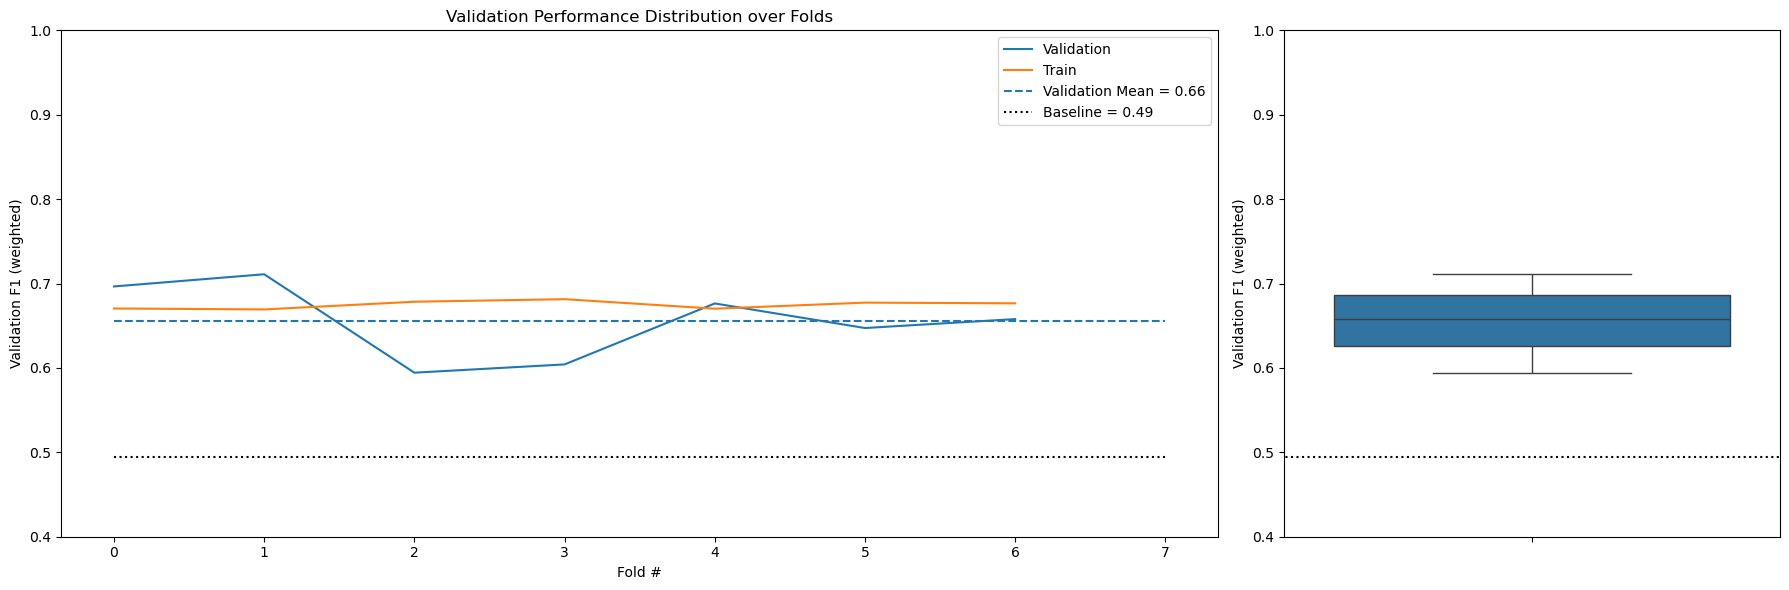

In [68]:
import seaborn as sns

val_mean = logistic_regression_gkf_fold_results["val_f1"].mean()
baseline_mean = y_voice.mean()

fig,axes = plt.subplots(1,2,figsize=(18,6),width_ratios=[0.7,0.3])

sns.lineplot(data=logistic_regression_gkf_fold_results,x="fold",y="val_f1",ax=axes[0],label="Validation")
sns.lineplot(data=logistic_regression_gkf_fold_results,x="fold",y="train_f1",ax=axes[0],label="Train")
axes[0].plot([0,n_splits],[val_mean, val_mean], ls="--",c="tab:blue",label=f"Validation Mean = {np.round(val_mean, 2)}")
axes[0].plot([0,n_splits],[baseline_mean, baseline_mean], ls="dotted",c="k",label=f"Baseline = {np.round(baseline_mean, 2)}")
axes[0].set_ylabel("Validation F1 (weighted)")
axes[0].set_ylim([0.4, 1.0])
axes[0].set_xlabel("Fold #")
axes[0].legend()
axes[0].set_title("Validation Performance Distribution over Folds")

sns.boxplot(data=logistic_regression_gkf_fold_results, y="val_f1",ax=axes[1])
axes[1].plot([-1,2], [baseline_mean, baseline_mean], ls="dotted", c="k")
axes[1].set_ylabel("Validation F1 (weighted)")
axes[1].set_xlim([-0.5, 0.5])
axes[1].set_ylim([0.4, 1.0])
plt.tight_layout()
plt.show()

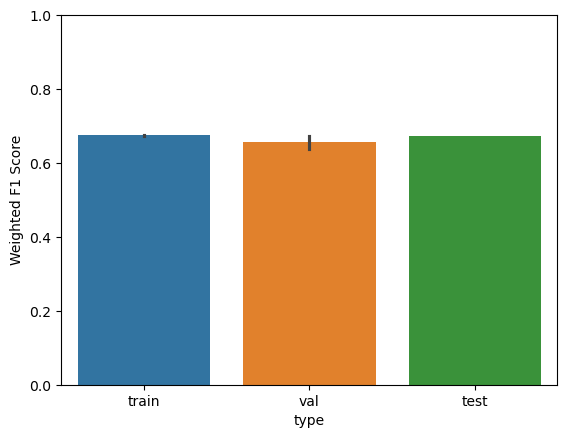

In [69]:
train_f1 = logistic_regression_gkf_fold_results["train_f1"].mean()
val_f1 = logistic_regression_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in logistic_regression_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.ylabel("Weighted F1 Score")
plt.ylim([0, 1.0])
plt.show()

In [70]:
train_mean = results_df[results_df["type"]=="train"]["f1"].mean()
val_mean = results_df[results_df["type"]=="val"]["f1"].mean()
test_score = results_df[results_df["type"]=="test"]["f1"].mean()
print(f"Train F1 = {np.round(train_mean,2)}")
print(f"Val F1 = {np.round(val_mean,2)}")
print(f"Test F1 = {np.round(test_score,2)}")

Train F1 = 0.67
Val F1 = 0.66
Test F1 = 0.67


## Coefficient Analysis for Feature Importance

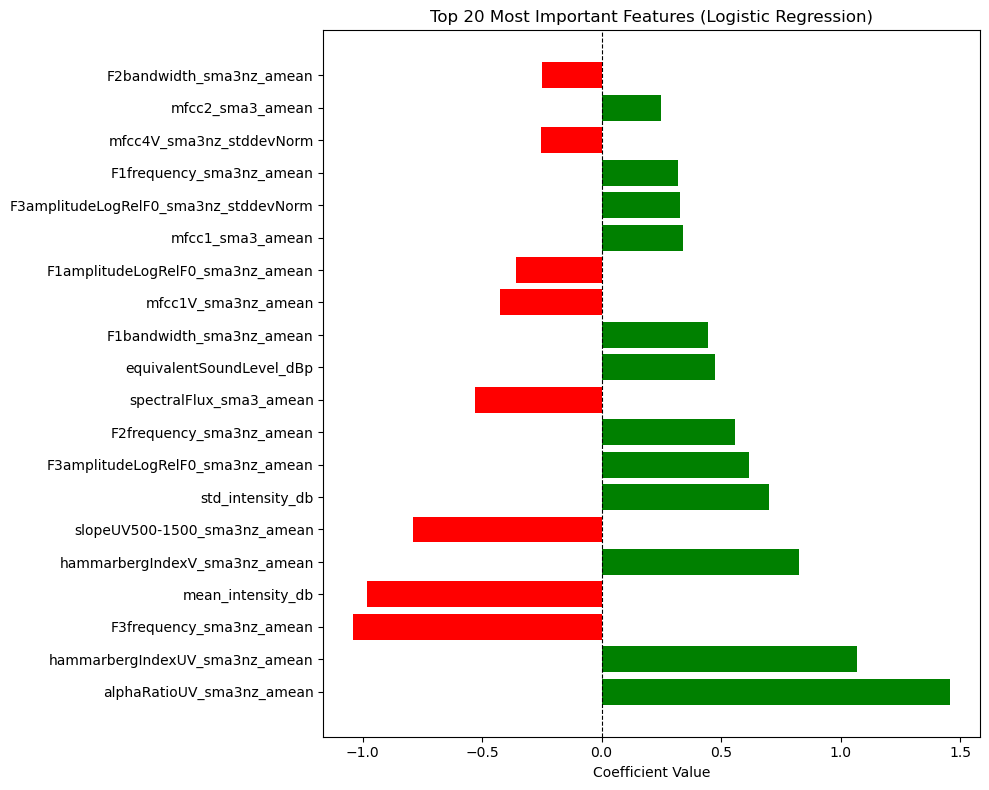


Top 10 most important features:
                             feature  coefficient  abs_coefficient
76         alphaRatioUV_sma3nz_amean     1.458024         1.458024
77    hammarbergIndexUV_sma3nz_amean     1.068057         1.068057
52          F3frequency_sma3nz_amean    -1.038926         1.038926
89                 mean_intensity_db    -0.981870         0.981870
60     hammarbergIndexV_sma3nz_amean     0.827525         0.827525
79      slopeUV500-1500_sma3nz_amean    -0.787249         0.787249
90                  std_intensity_db     0.698830         0.698830
56  F3amplitudeLogRelF0_sma3nz_amean     0.614771         0.614771
46          F2frequency_sma3nz_amean     0.557462         0.557462
20           spectralFlux_sma3_amean    -0.529620         0.529620


In [77]:
def plot_logistic_coefficients(model, feature_names, top_n=20):
    """
    Extract and visualize logistic regression coefficients
    model: trained pipeline with ('scaler', 'logreg')
    """
    # Extract the logistic regression coefficients
    logreg = model.named_steps['logreg']
    coefficients = logreg.coef_[0]  # For binary classification
    
    # Create dataframe with feature names and coefficients
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)
    
    # Plot top N features
    top_features = coef_df.head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
    ax.barh(range(len(top_features)), top_features['coefficient'], color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.set_xlabel('Coefficient Value')
    ax.set_title(f'Top {top_n} Most Important Features (Logistic Regression)')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    
    return coef_df

# Usage
best_model = grid_search_voice['best_estimator']
coef_importance = plot_logistic_coefficients(best_model, feature_names, top_n=20)

# perm_importance = plot_permutation_importance(
#     best_model, X_train, y_train, feature_names, top_n=20
# )

# odds_ratios = plot_odds_ratios(best_model, feature_names, top_n=20)


print("\nTop 10 most important features:")
print(coef_importance.head(10))

## Error Analysis

In [79]:
def error_analysis(model, X_test, y_test, feature_names, class_names=None, top_n=20):
    """
    Detailed error analysis: which samples are misclassified and why
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Get prediction confidence (max probability)
    confidence = np.max(y_pred_proba, axis=1)
    
    # Identify correct and incorrect predictions
    correct_mask = (y_test == y_pred)
    incorrect_mask = ~correct_mask
    
    print("="*70)
    print("ERROR ANALYSIS")
    print("="*70)
    print(f"\nTotal samples: {len(y_test)}")
    print(f"Correct predictions: {correct_mask.sum()} ({100*correct_mask.mean():.2f}%)")
    print(f"Incorrect predictions: {incorrect_mask.sum()} ({100*incorrect_mask.mean():.2f}%)")
    
    # Confidence distribution for correct vs incorrect
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Confidence distributions
    axes[0, 0].hist(confidence[correct_mask], bins=30, alpha=0.7, label='Correct', color='green')
    axes[0, 0].hist(confidence[incorrect_mask], bins=30, alpha=0.7, label='Incorrect', color='red')
    axes[0, 0].set_xlabel('Prediction Confidence')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Confidence Distribution: Correct vs Incorrect')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. Confidence by correctness
    axes[0, 1].boxplot([confidence[correct_mask], confidence[incorrect_mask]], 
                       labels=['Correct', 'Incorrect'])
    axes[0, 1].set_ylabel('Prediction Confidence')
    axes[0, 1].set_title('Confidence Comparison')
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Error rate by confidence bins
    confidence_bins = np.linspace(0, 1, 11)
    bin_centers = (confidence_bins[:-1] + confidence_bins[1:]) / 2
    error_rates = []
    bin_counts = []
    
    for i in range(len(confidence_bins)-1):
        mask = (confidence >= confidence_bins[i]) & (confidence < confidence_bins[i+1])
        if mask.sum() > 0:
            error_rates.append(1 - correct_mask[mask].mean())
            bin_counts.append(mask.sum())
        else:
            error_rates.append(0)
            bin_counts.append(0)
    
    axes[1, 0].bar(bin_centers, error_rates, width=0.08, alpha=0.7, color='coral')
    axes[1, 0].set_xlabel('Confidence Bin')
    axes[1, 0].set_ylabel('Error Rate')
    axes[1, 0].set_title('Error Rate by Confidence Level')
    axes[1, 0].grid(alpha=0.3)
    
    # 4. Sample counts per bin
    axes[1, 1].bar(bin_centers, bin_counts, width=0.08, alpha=0.7, color='skyblue')
    axes[1, 1].set_xlabel('Confidence Bin')
    axes[1, 1].set_ylabel('Number of Samples')
    axes[1, 1].set_title('Sample Distribution by Confidence')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Analyze misclassified samples
    print("\n" + "="*70)
    print("MISCLASSIFICATION PATTERNS")
    print("="*70)
    
    if class_names is not None:
        # Confusion pairs
        from collections import Counter
        misclass_pairs = Counter(zip(y_test[incorrect_mask], y_pred[incorrect_mask]))
        print("\nMost common misclassification pairs (True → Predicted):")
        for (true_label, pred_label), count in misclass_pairs.most_common(10):
            print(f"  {class_names[true_label]} → {class_names[pred_label]}: {count} samples")
    
    # Most confident errors (high confidence but wrong)
    high_conf_errors = incorrect_mask & (confidence > 0.8)
    print(f"\nHigh-confidence errors (>0.8): {high_conf_errors.sum()} samples")
    
    # Low confidence correct (correct but uncertain)
    low_conf_correct = correct_mask & (confidence < 0.6)
    print(f"Low-confidence correct predictions (<0.6): {low_conf_correct.sum()} samples")
    
    # Feature analysis for errors
    if len(feature_names) <= 100:  # Only if reasonable number of features
        plot_error_feature_analysis(X_test, correct_mask, feature_names, top_n)
    
    return {
        'correct_mask': correct_mask,
        'confidence': confidence,
        'high_conf_errors': high_conf_errors,
        'low_conf_correct': low_conf_correct
    }

def plot_error_feature_analysis(X_test, correct_mask, feature_names, top_n=20):
    """
    Compare feature distributions for correct vs incorrect predictions
    """
    # Calculate mean difference in features between correct and incorrect
    mean_correct = X_test[correct_mask].mean(axis=0)
    mean_incorrect = X_test[~correct_mask].mean(axis=0)
    mean_diff = np.abs(mean_correct - mean_incorrect)
    
    # Get top features with biggest difference
    top_indices = np.argsort(mean_diff)[-top_n:][::-1]
    
    fig, axes = plt.subplots(4, 5, figsize=(20, 12))
    axes = axes.flatten()
    
    for i, idx in enumerate(top_indices[:20]):
        axes[i].hist(X_test[correct_mask, idx], bins=20, alpha=0.6, 
                    label='Correct', color='green', density=True)
        axes[i].hist(X_test[~correct_mask, idx], bins=20, alpha=0.6, 
                    label='Incorrect', color='red', density=True)
        axes[i].set_title(f'{feature_names[idx]}', fontsize=8)
        axes[i].tick_params(labelsize=6)
        if i == 0:
            axes[i].legend(fontsize=6)
    
    plt.suptitle('Feature Distributions: Correct vs Incorrect Predictions', fontsize=14)
    plt.tight_layout()
    plt.show()

ERROR ANALYSIS

Total samples: 3154
Correct predictions: 2116 (67.09%)
Incorrect predictions: 1038 (32.91%)


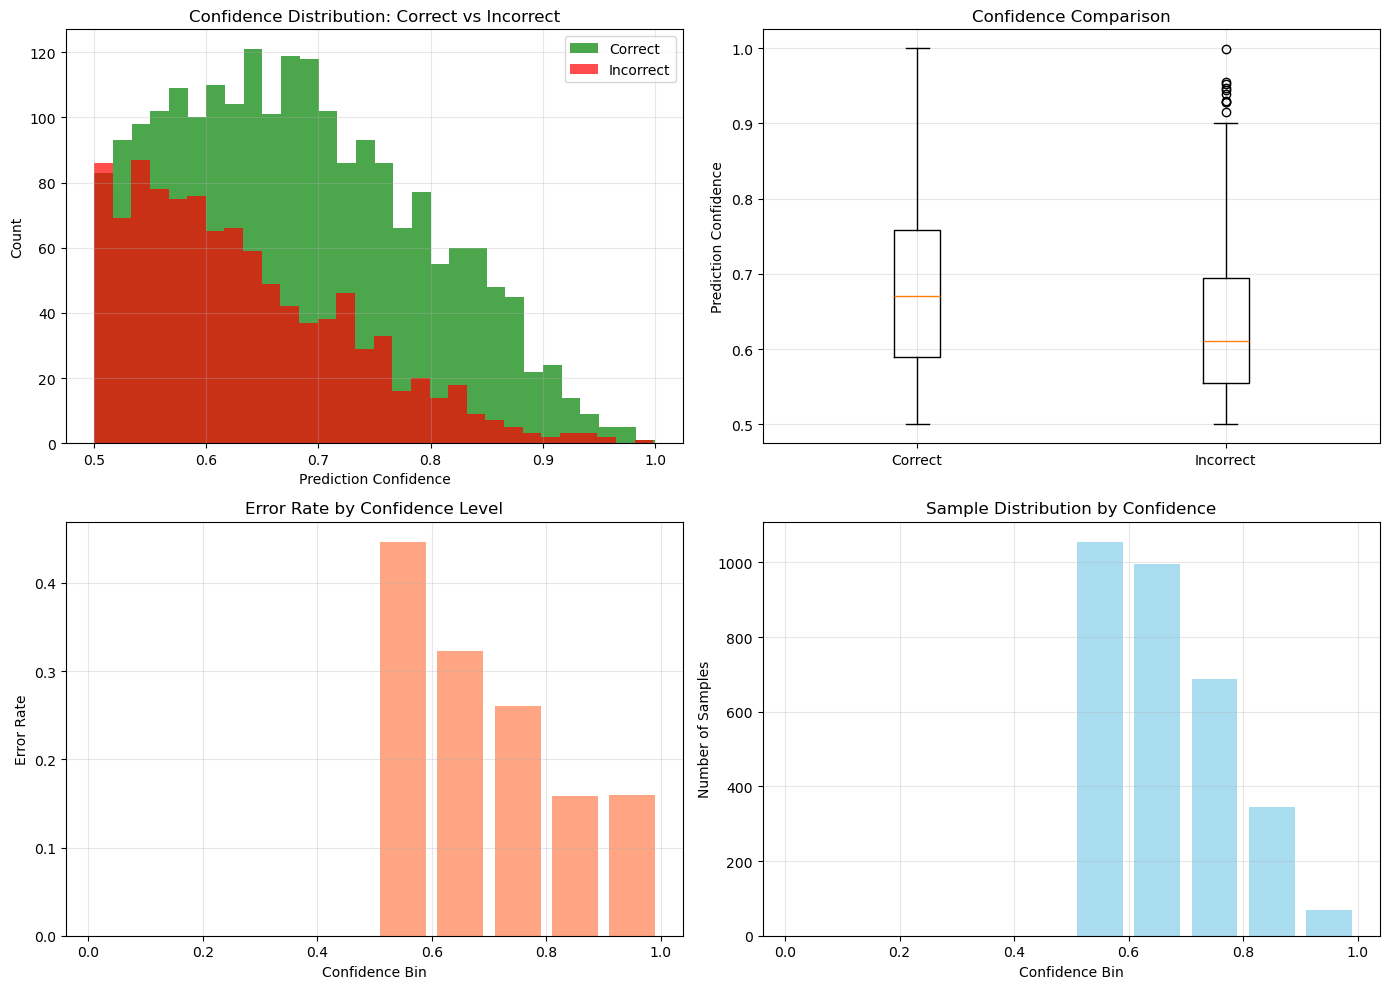


MISCLASSIFICATION PATTERNS

Most common misclassification pairs (True → Predicted):
  No Voice Disorder → Voice Disorder: 560 samples
  Voice Disorder → No Voice Disorder: 478 samples

High-confidence errors (>0.8): 66 samples
Low-confidence correct predictions (<0.6): 584 samples


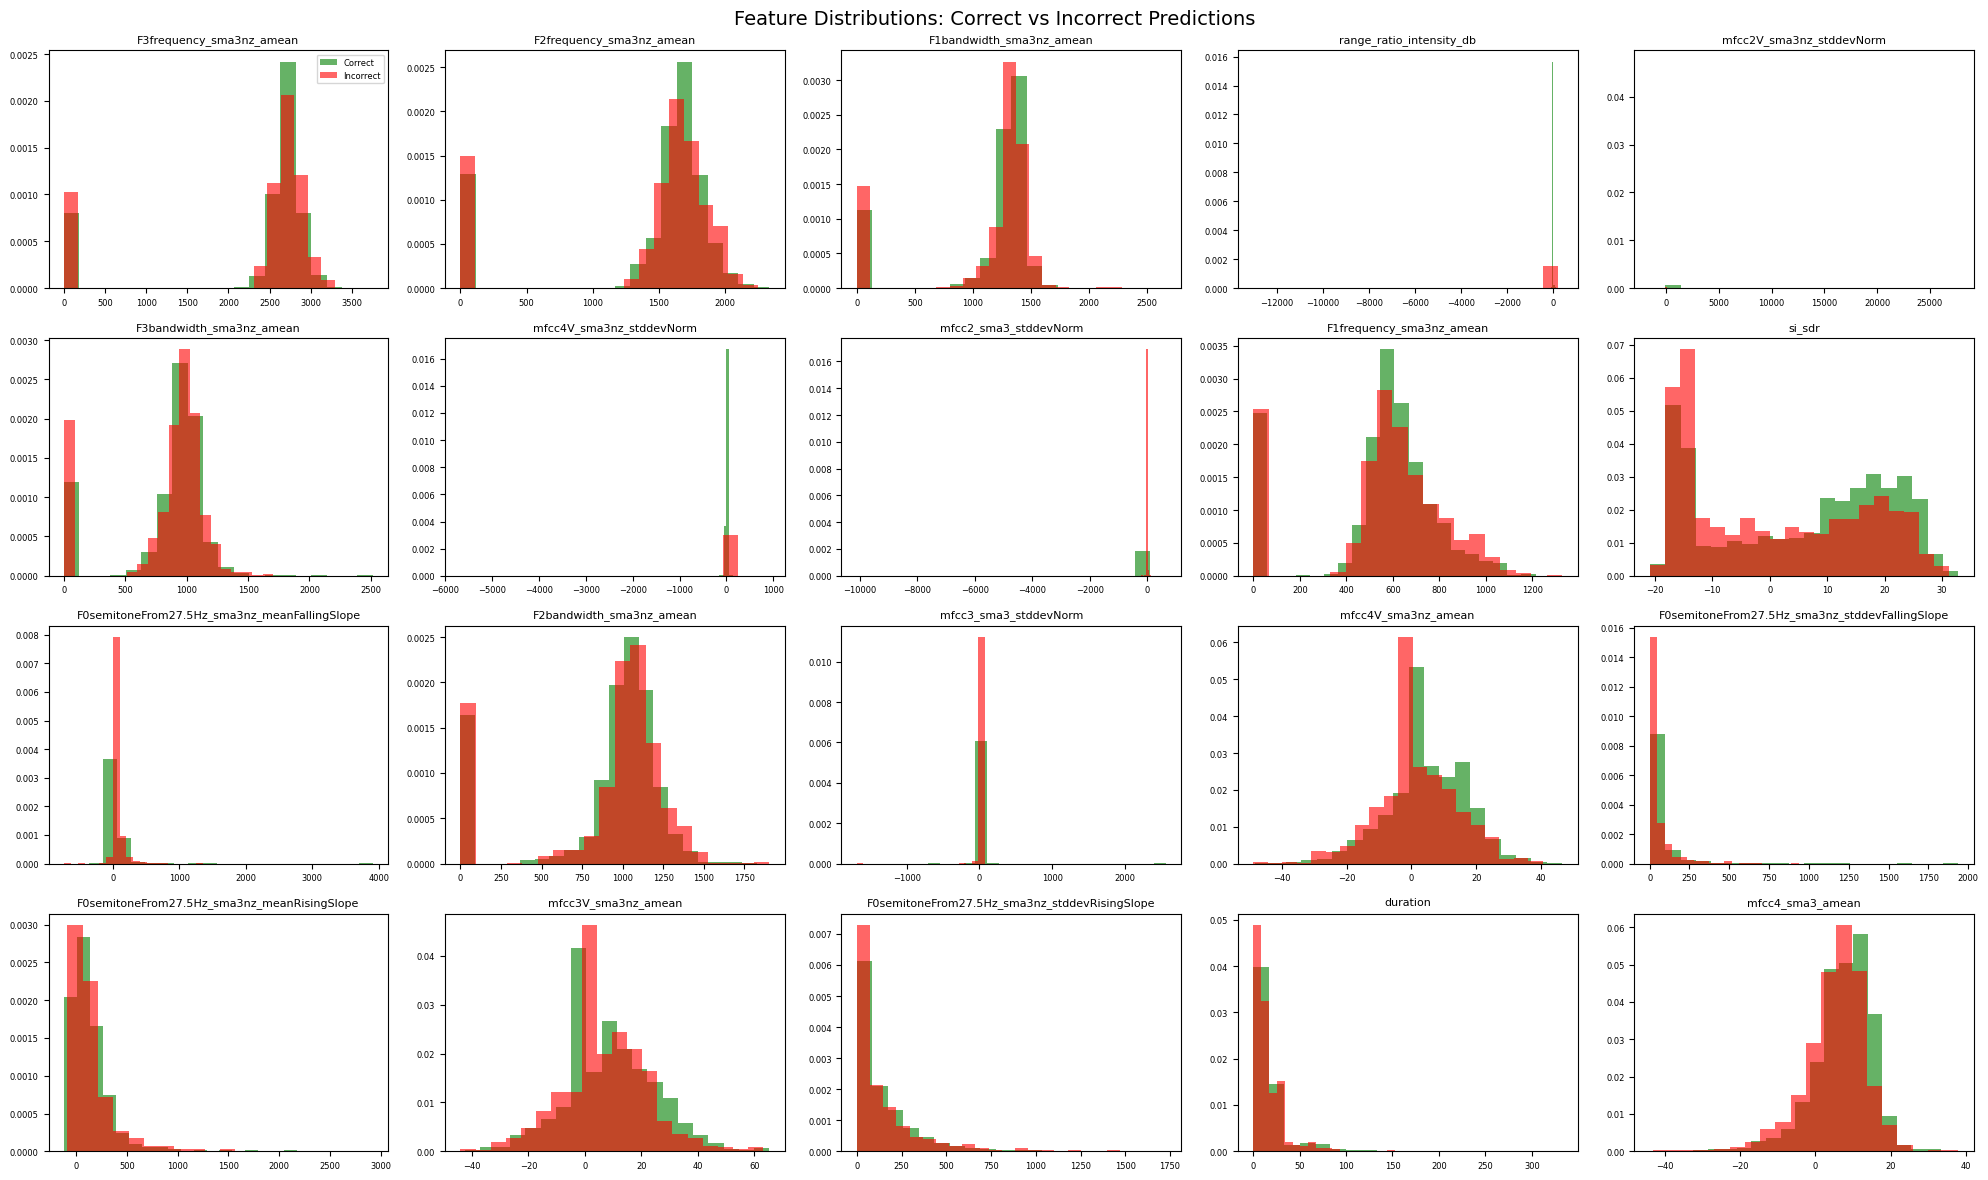

In [80]:
best_model = grid_search_voice['best_estimator']
class_names = ['No Voice Disorder', 'Voice Disorder']

error_results = error_analysis(
        best_model, X_test, y_test, feature_names, class_names, top_n=20)

In [78]:
# save model
import pickle
filepath = 'models/logistic-regression-trained.pkl'
with open(filepath, 'wb') as file:
    pickle.dump(clf, file)